# Discussion 6 Assignment

Alexander Zhang  
alexacz1@uci.edu

## Setup  
Load dependencies and set up environment for discussion 6.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

sns.set_theme(style="whitegrid", palette="muted")

print("Fetching Glioma Grading Clinical and Mutation Features dataset (ID: 759)...")

glioma_dataset = fetch_ucirepo(id=759) 

X = glioma_dataset.data.features 
y = glioma_dataset.data.targets

y = y.iloc[:, 0]

if 'Case_ID' in X.columns:
    X = X.drop(columns=['Case_ID'])

print(f"Dataset successfully loaded!")
print(f"Total Patients: {X.shape[0]} | Total Features: {X.shape[1]}")

Note: you may need to restart the kernel to use updated packages.
Fetching Glioma Grading Clinical and Mutation Features dataset (ID: 759)...
Dataset successfully loaded!
Total Patients: 839 | Total Features: 23


## Summarization & Visualization

The distribution of Glioma grades needs to be visualized, as well as the demographics (Race), to understand the AIM-AHEAD context of the data.


--- DATA SUMMARIZATION ---
Target Class Distribution:
Grade
0    58.0
1    42.0
Name: proportion, dtype: float64


/var/folders/k8/p0zmwvf53y155yg14pkmym6w0000gp/T/ipykernel_72505/4003027184.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')
/var/folders/k8/p0zmwvf53y155yg14pkmym6w0000gp/T/ipykernel_72505/4003027184.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[race_col], palette='Set2', order=X[race_col].value_counts().index)


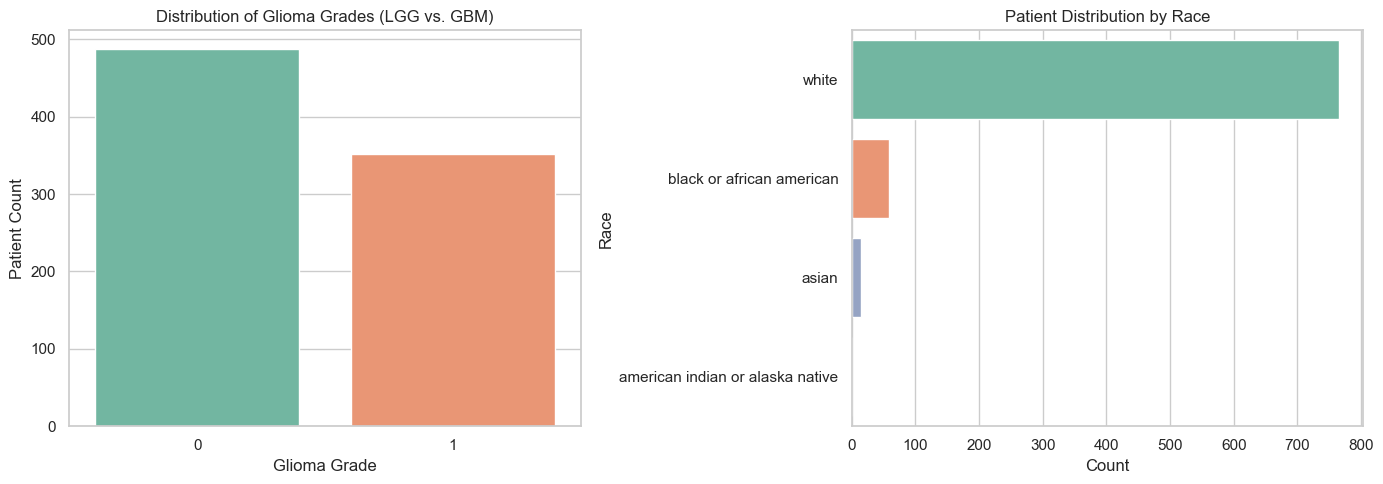

In [2]:
print("\n--- DATA SUMMARIZATION ---")
print("Target Class Distribution:")
print(y.value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y, palette='Set2')
plt.title("Distribution of Glioma Grades (LGG vs. GBM)")
plt.xlabel("Glioma Grade")
plt.ylabel("Patient Count")


plt.subplot(1, 2, 2)
race_col = 'Race' if 'Race' in X.columns else 'race' if 'race' in X.columns else None

if race_col:
    sns.countplot(y=X[race_col], palette='Set2', order=X[race_col].value_counts().index)
    plt.title("Patient Distribution by Race")
    plt.xlabel("Count")
    plt.ylabel("Race")
else:
    print("Race column not found for plotting.")

plt.tight_layout()
plt.show()